# Stage transitions: what fine-tuning changes (axis-200-900)

How does the improvement over the baseline evolve along a lineage (pretrained -> frozen head -> unfrozen head), and what does each fine-tuning step change within a lineage?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

* Transition $A \to B$ within one lineage (same variant and repetition): $s_m(v^{B}_r - v^{A}_r)$; positive = stage
  $B$ is better than stage $A$ of the same pretrained model.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_transitions"
AXIS = "axis-200-900"
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

stage_improvements = table('stage_improvements')
transition_summary = table('transition_summary')
transitions = table('transitions')
TRANSITIONS = ['frozen_minus_pretrained', 'unfrozen_minus_pretrained', 'unfrozen_minus_frozen']

Analysis: stage_transitions | axis: axis-200-900 | stage: None | models: 155
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_transitions` computes the key and complete metric table of every model of the axis, the summary of
each stage against the baseline, and the paired differences between stages of one lineage.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_transitions > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute key metrics at every stage against the real-only baseline

### Methodology

#### Theoretical

Transitions below are differences between stages; this section shows the level of every key metric for the
real-only baseline and for every variant at every stage.

#### Implementation

`model_metrics` holds one value per model (all stages and the baseline).

#### Figure descriptions

        Figure: one panel per metric; x = real-only baseline and the stages (every variant's repetitions pooled per
        stage; 50 models per stage against 5 baseline models), violin and points = models. Tables (one per metric): rows
        = baseline and variants, columns = stages; the baseline row repeats the baseline value in every stage column so
        that each cell is compared with it.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

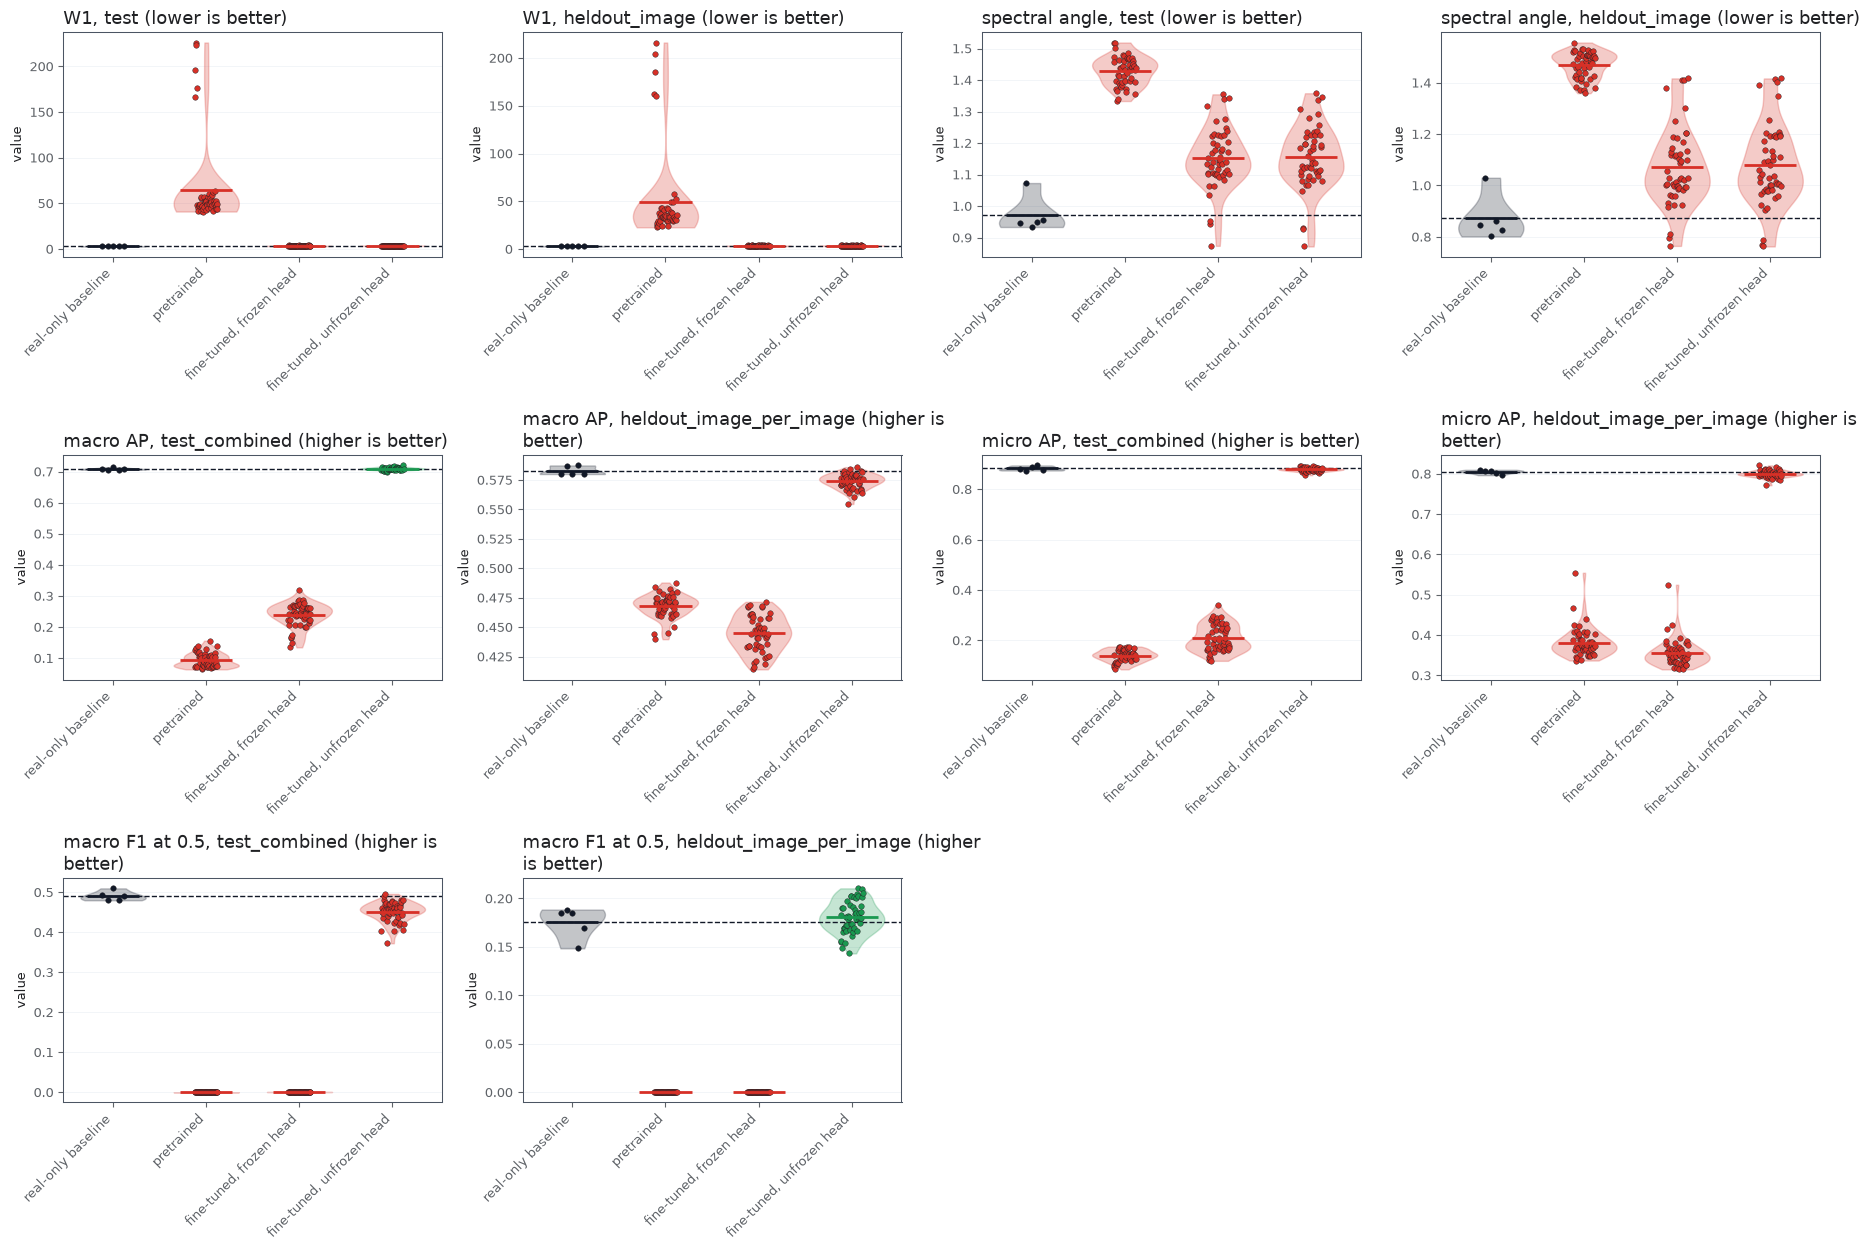

W1, test


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,3.117 +/- 0.109,3.117 +/- 0.109,3.117 +/- 0.109
P0_single,197.775 +/- 26.938,3.479 +/- 0.409,3.486 +/- 0.119
P1_permutation,46.056 +/- 2.657,2.938 +/- 0.062,3.025 +/- 0.142
P2_joint_base,50.160 +/- 6.343,3.493 +/- 0.256,3.427 +/- 0.086
P2_staged_base,45.214 +/- 2.680,3.318 +/- 0.220,3.175 +/- 0.186
P3_joint_overlap,52.983 +/- 2.360,3.540 +/- 0.352,3.468 +/- 0.181
P3_staged_overlap,48.194 +/- 5.284,3.220 +/- 0.242,3.249 +/- 0.157
P4_joint_rare,53.377 +/- 4.432,3.424 +/- 0.221,3.490 +/- 0.224
P4_staged_rare,48.983 +/- 6.597,3.291 +/- 0.312,3.436 +/- 0.222


W1, heldout_image


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,3.076 +/- 0.143,3.076 +/- 0.143,3.076 +/- 0.143
P0_single,185.632 +/- 24.787,3.715 +/- 0.525,3.678 +/- 0.191
P1_permutation,25.799 +/- 2.581,2.966 +/- 0.114,3.123 +/- 0.337
P2_joint_base,34.328 +/- 5.988,3.475 +/- 0.353,3.320 +/- 0.277
P2_staged_base,34.137 +/- 6.829,3.297 +/- 0.289,3.213 +/- 0.245
P3_joint_overlap,34.893 +/- 3.518,3.435 +/- 0.502,3.494 +/- 0.379
P3_staged_overlap,33.563 +/- 5.702,3.206 +/- 0.349,3.426 +/- 0.280
P4_joint_rare,33.484 +/- 6.357,3.482 +/- 0.332,3.382 +/- 0.086
P4_staged_rare,38.207 +/- 6.986,3.399 +/- 0.403,3.597 +/- 0.173


spectral angle, test


...

stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.805 +/- 0.005,0.805 +/- 0.005,0.805 +/- 0.005
P0_single,0.449 +/- 0.066,0.413 +/- 0.066,0.805 +/- 0.011
P1_permutation,0.352 +/- 0.014,0.350 +/- 0.013,0.799 +/- 0.003
P2_joint_base,0.401 +/- 0.020,0.363 +/- 0.036,0.806 +/- 0.005
P2_staged_base,0.368 +/- 0.022,0.343 +/- 0.023,0.792 +/- 0.013
P3_joint_overlap,0.380 +/- 0.019,0.349 +/- 0.015,0.803 +/- 0.008
P3_staged_overlap,0.373 +/- 0.016,0.339 +/- 0.024,0.797 +/- 0.006
P4_joint_rare,0.384 +/- 0.039,0.358 +/- 0.024,0.801 +/- 0.003
P4_staged_rare,0.365 +/- 0.018,0.336 +/- 0.018,0.803 +/- 0.008


macro F1 at 0.5, test_combined


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.491 +/- 0.012,0.491 +/- 0.012,0.491 +/- 0.012
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.440 +/- 0.023
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.479 +/- 0.016
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.438 +/- 0.040
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.454 +/- 0.011
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.467 +/- 0.011
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.438 +/- 0.025
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.455 +/- 0.017
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.442 +/- 0.016


macro F1 at 0.5, heldout_image_per_image


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.175 +/- 0.017,0.175 +/- 0.017,0.175 +/- 0.017
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.167 +/- 0.019
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.170 +/- 0.013
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.177 +/- 0.012
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.171 +/- 0.016
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.188 +/- 0.017
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.178 +/- 0.017
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.185 +/- 0.011
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.193 +/- 0.019


In [4]:
frame_abs = table('model_metrics')

SELECTORS_ABS = [["W1, test", {"family": "reconstruction", "metric": "masserstein", "evaluation": "test", "ranking": "none"}, "lower"], ["W1, heldout_image", {"family": "reconstruction", "metric": "masserstein", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["spectral angle, test", {"family": "reconstruction", "metric": "spectral_angle", "evaluation": "test", "ranking": "none"}, "lower"], ["spectral angle, heldout_image", {"family": "reconstruction", "metric": "spectral_angle", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["macro AP, test_combined", {"family": "prediction", "metric": "average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["macro AP, heldout_image_per_image", {"family": "prediction", "metric": "average_precision", "evaluation": "heldout_image_per_image", "ranking": "annotation_retrieval"}, "higher"], ["micro AP, test_combined", {"family": "prediction", "metric": "micro_average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["micro AP, heldout_image_per_image", {"family": "prediction", "metric": "micro_average_precision", "evaluation": "heldout_image_per_image", "ranking": "annotation_retrieval"}, "higher"], ["macro F1 at 0.5, test_combined", {"family": "prediction", "metric": "f1", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["macro F1 at 0.5, heldout_image_per_image", {"family": "prediction", "metric": "f1", "evaluation": "heldout_image_per_image", "ranking": "annotation_retrieval"}, "higher"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(frame_abs, panels=[(label, selector, direction) for label, selector, direction in SELECTORS_ABS], group='stage',
                      order=STAGE_ORDER, labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for label, selector, direction in SELECTORS_ABS:
    rows = frame_abs
    for column, value in selector.items():
        rows = rows[rows[column] == value]
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    print(label)
    display(figures.comparison_table(grid, index='variant', columns='stage', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=STAGES, direction={stage: direction for stage in STAGES}))

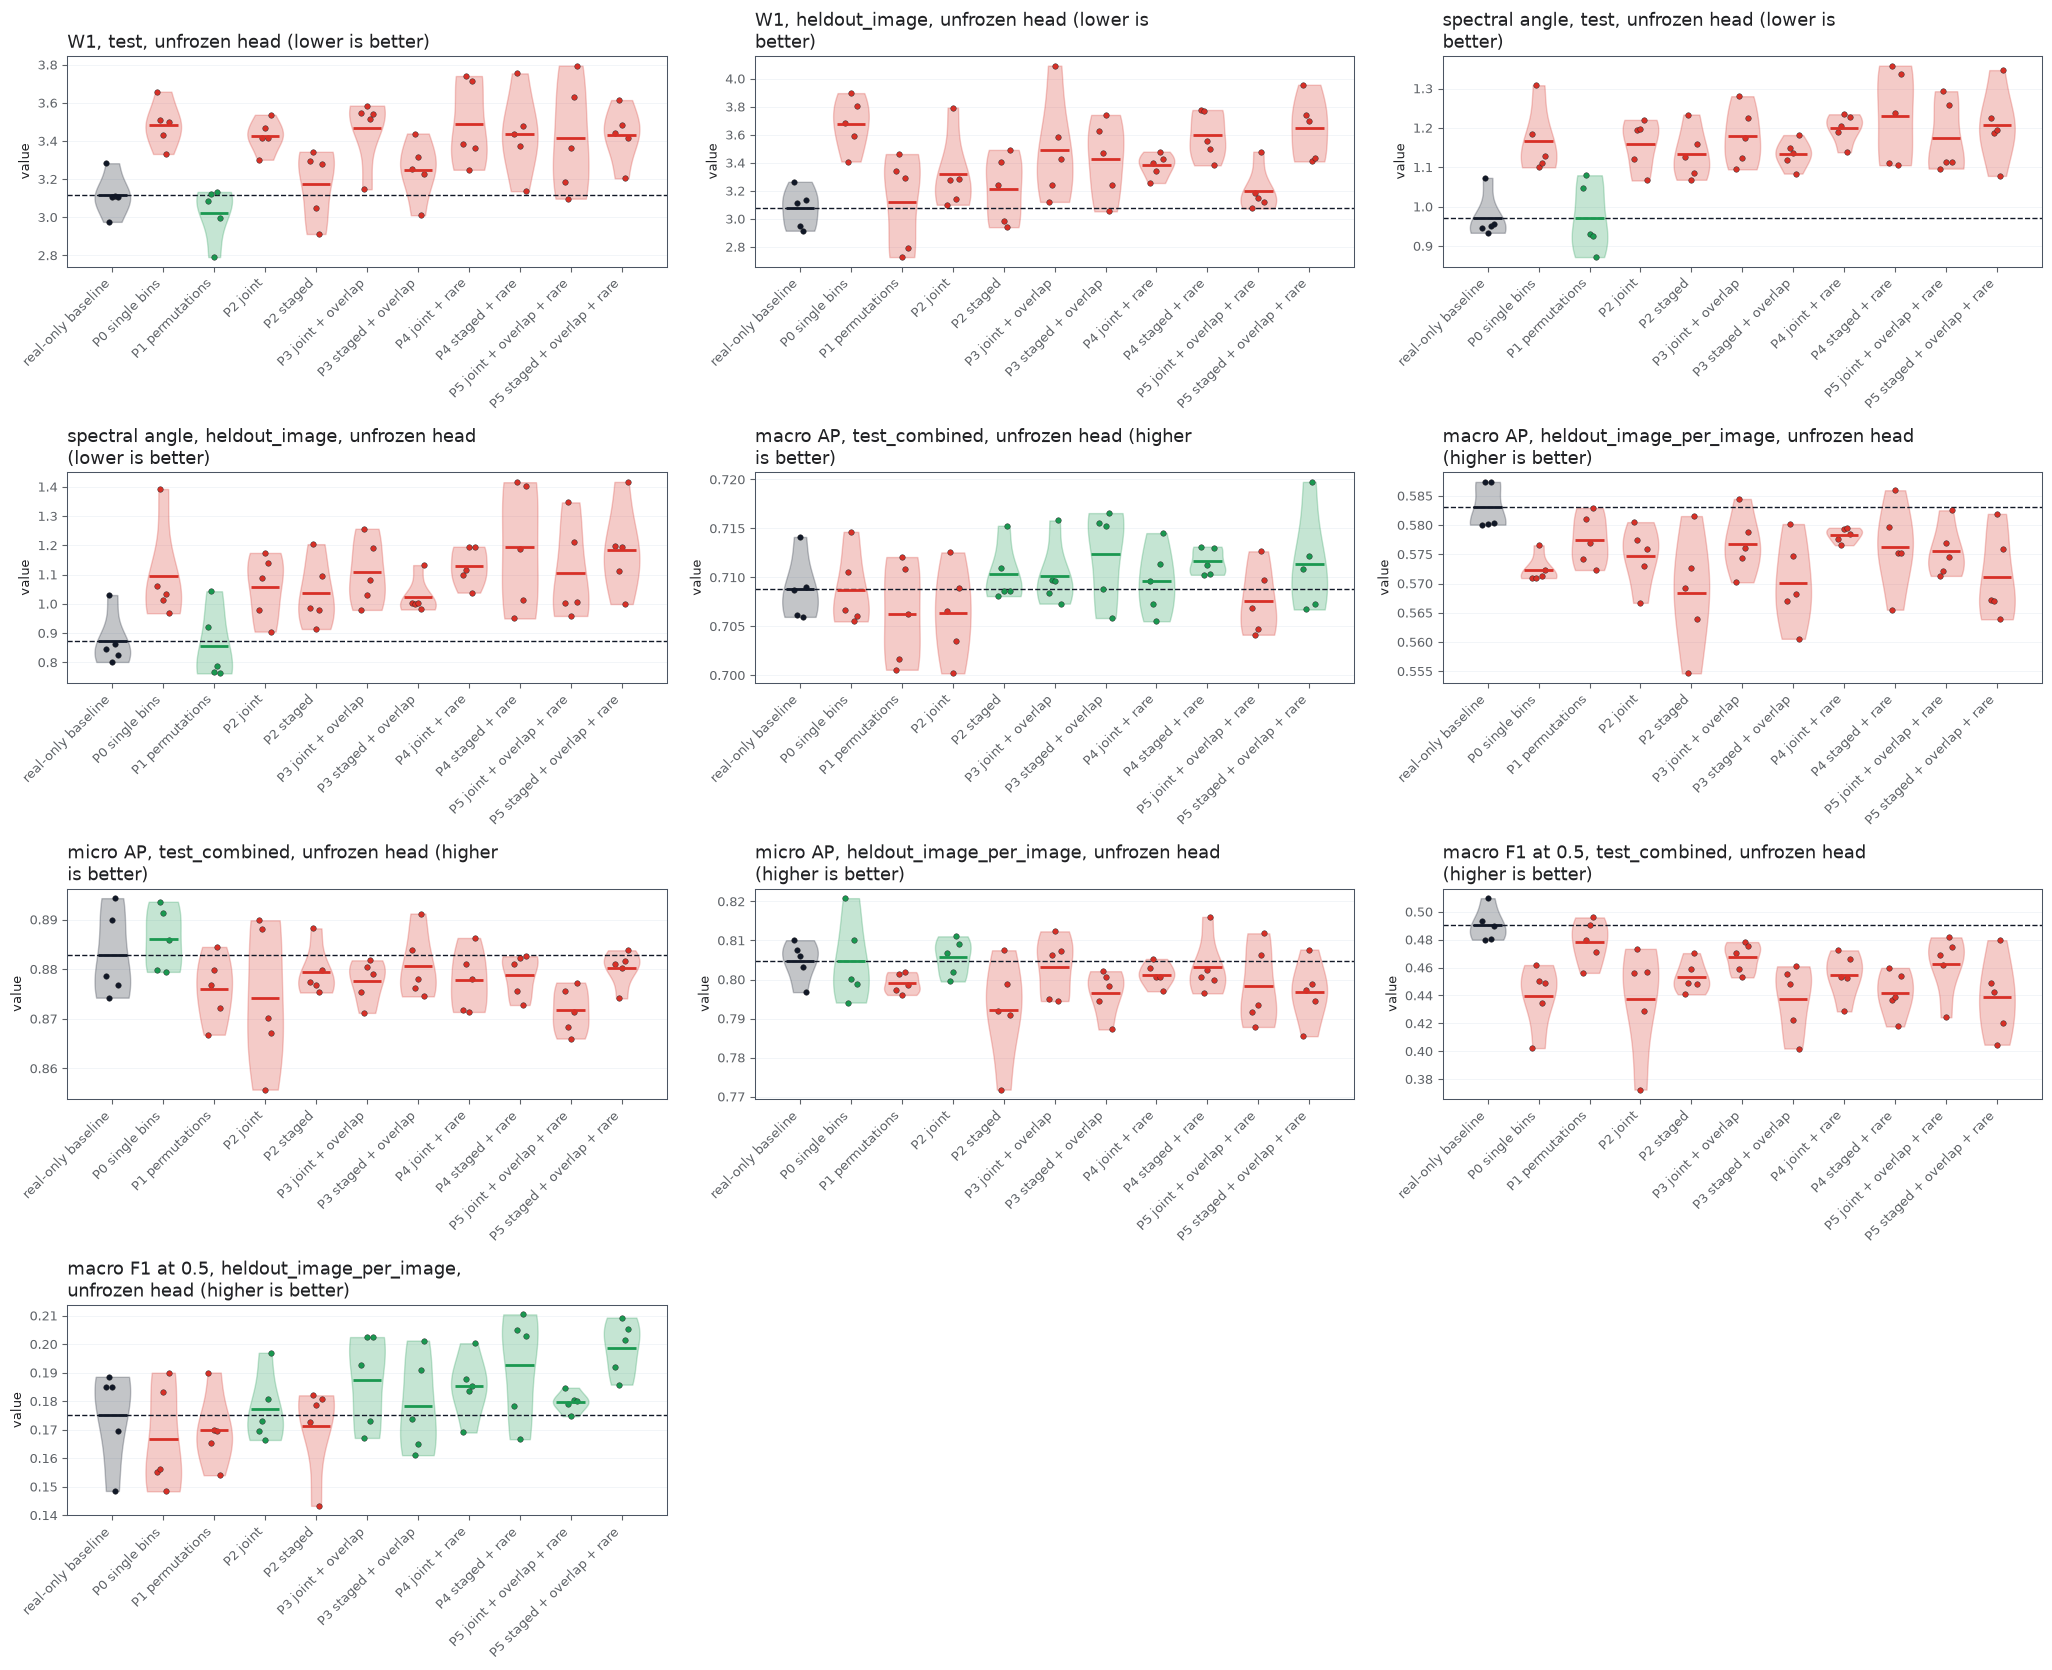

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- W1, test (by stage, variants pooled): baseline 3.117; others 3.36-64.55; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.36), worst pretrained (64.55).
- W1, test (unfrozen head, per variant): baseline 3.117; others 3.025-3.49; 1 of 10 better than the baseline; best P1 permutations (3.025), worst P4 joint + rare (3.49).
  best single cell: P1 permutations, fine-tuned, frozen head (2.938 vs baseline 3.117).
- W1, heldout_image (by stage, variants pooled): baseline 3.076; others 3.401-49.63; 0 of 3 better than the baseline; best fine-tuned, frozen head (3.401), worst pretrained (49.63).
- W1, heldout_image (unfrozen head, per variant): baseline 3.076; others 3.123-3.678; 0 of 10 better than the baseline; best P1 permutations (3.123), worst P0 single bins (3.678).
  best single cell: P1 permutations, fine-tuned, frozen head (2.966 vs baseline 3.076).
- spectral angle, test (by stage, variants pooled): baseline 0.9716; others 1.153-1.429; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.153), worst pretrained (1.429).
- spectral angle, test (unfrozen head, per variant): baseline 0.9716; others 0.9711-1.23; 1 of 10 better than the baseline; best P1 permutations (0.9711), worst P4 staged + rare (1.23).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9711 vs baseline 0.9716).
- spectral angle, heldout_image (by stage, variants pooled): baseline 0.8726; others 1.07-1.47; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.07), worst pretrained (1.47).
- spectral angle, heldout_image (unfrozen head, per variant): baseline 0.8726; others 0.8567-1.194; 1 of 10 better than the baseline; best P1 permutations (0.8567), worst P4 staged + rare (1.194).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.8567 vs baseline 0.8726).
- macro AP, test_combined (by stage, variants pooled): baseline 0.7088; others 0.09429-0.7094; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7094), worst pretrained (0.09429).
- macro AP, test_combined (unfrozen head, per variant): baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
  best single cell: P3 staged + overlap, fine-tuned, unfrozen head (0.7124 vs baseline 0.7088).
- macro AP, heldout_image_per_image (by stage, variants pooled): baseline 0.5831; others 0.4448-0.5741; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5741), worst fine-tuned, frozen head (0.4448).
- macro AP, heldout_image_per_image (unfrozen head, per variant): baseline 0.5831; others 0.5684-0.5783; 0 of 10 better than the baseline; best P4 joint + rare (0.5783), worst P2 staged (0.5684).
  best single cell: P4 joint + rare, fine-tuned, unfrozen head (0.5783 vs baseline 0.5831).
- micro AP, test_combined (by stage, variants pooled): baseline 0.8828; others 0.1399-0.8783; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8783), worst pretrained (0.1399).
- micro AP, test_combined (unfrozen head, per variant): baseline 0.8828; others 0.8717-0.886; 1 of 10 better than the baseline; best P0 single bins (0.886), worst P5 joint + overlap + rare (0.8717).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.886 vs baseline 0.8828).
- micro AP, heldout_image_per_image (by stage, variants pooled): baseline 0.8048; others 0.3553-0.8001; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8001), worst fine-tuned, frozen head (0.3553).
- micro AP, heldout_image_per_image (unfrozen head, per variant): baseline 0.8048; others 0.7922-0.8057; 2 of 10 better than the baseline; best P2 joint (0.8057), worst P2 staged (0.7922).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.8057 vs baseline 0.8048).
- macro F1 at 0.5, test_combined (by stage, variants pooled): baseline 0.4908; others 1.535e-07-0.4512; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4512), worst fine-tuned, frozen head (1.535e-07).
- macro F1 at 0.5, test_combined (unfrozen head, per variant): baseline 0.4908; others 0.4376-0.4787; 0 of 10 better than the baseline; best P1 permutations (0.4787), worst P2 joint (0.4376).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.4787 vs baseline 0.4908).
- macro F1 at 0.5, heldout_image_per_image (by stage, variants pooled): baseline 0.1753; others 0-0.1808; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.1808), worst fine-tuned, frozen head (0).
- macro F1 at 0.5, heldout_image_per_image (unfrozen head, per variant): baseline 0.1753; others 0.1666-0.1988; 7 of 10 better than the baseline; best P5 staged + overlap + rare (0.1988), worst P0 single bins (0.1666).
  best single cell: P5 staged + overlap + rare, fine-tuned, unfrozen head (0.1988 vs baseline 0.1753).

### Notes

## Improvement over the baseline along the lineage

### Methodology

#### Theoretical

For every key metric the mean improvement of each variant over the baseline at each stage; the path shows
whether fine-tuning closes the gap to the baseline, overtakes it or stays behind.

#### Implementation

`stage_improvements` (summary per variant, stage and metric).

#### Figure descriptions

One panel per key metric and evaluation; x = stage, one line per variant through the stage means, bars = 95 %
intervals, dashed line = baseline. The pretrained stage is far below zero for reconstruction; the y axis is
symmetric-log.

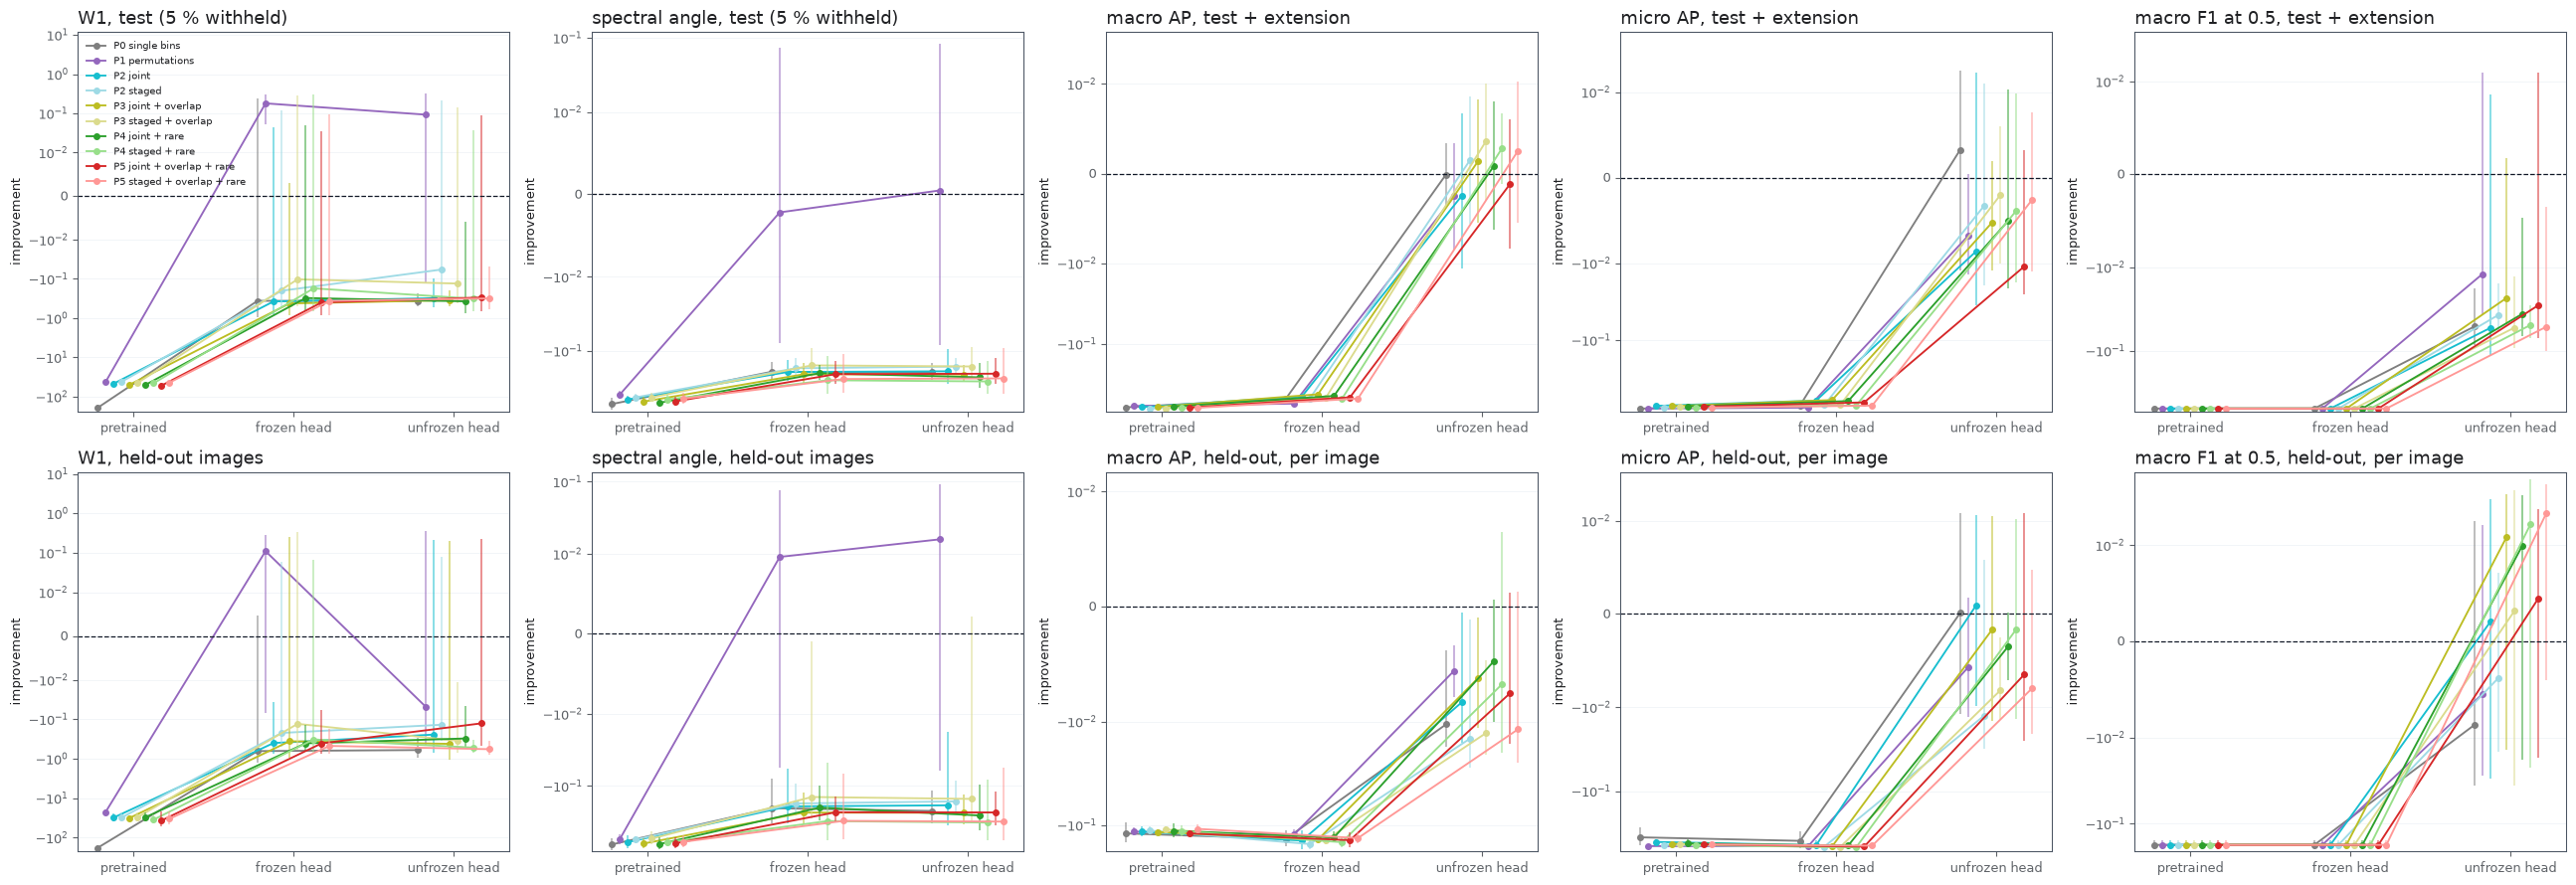

In [6]:
panels = key_panels()
figure, axes = plt.subplots(2, 5, figsize=(26, 9), dpi=theme.figure_dpi)
for ax, (title, selector) in zip(axes.T.flat, panels):
    rows = stage_improvements
    for column, value in selector.items():
        rows = rows[rows[column] == value]
    figures.stage_paths(rows, stages=STAGES, stage_labels={'pretrained': 'pretrained', 'frozen_head': 'frozen head', 'unfrozen_head': 'unfrozen head'},
                        variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, ylabel='improvement', title=title, ax=ax, theme=theme)
    ax.set_yscale('symlog', linthresh=1e-2)
axes[0, 0].legend(frameon=False, fontsize=7)
figure.tight_layout()

### Remarks

- pretrained: 0 improving, 130 worsening of 130 variant x key-metric cells.
- frozen head: 1 improving, 112 worsening of 130 variant x key-metric cells.
- unfrozen head: 1 improving, 43 worsening of 130 variant x key-metric cells.

### Notes

## Paired changes between stages of one lineage

### Methodology

#### Theoretical

Within a lineage the pretrained, frozen-head and unfrozen-head models share the pretrained weights, so their
differences isolate the effect of 10 real epochs (frozen: representation only; unfrozen: representation and
head) and of unfreezing the head.

#### Implementation

`transitions` (per lineage) and `transition_summary`.

#### Figure descriptions

Forest plot: rows = variants, panels = transition x key metric on test / test + extension. The table gives
the held-out values.

column,frozen_minus_pretrained | W1 | heldout_image,frozen_minus_pretrained | macro AP | heldout_image,frozen_minus_pretrained | macro AP | heldout_image_per_image,frozen_minus_pretrained | macro F1 at 0.5 | heldout_image,frozen_minus_pretrained | macro F1 at 0.5 | heldout_image_per_image,frozen_minus_pretrained | micro AP | heldout_image,frozen_minus_pretrained | micro AP | heldout_image_per_image,frozen_minus_pretrained | spectral angle | heldout_image,unfrozen_minus_frozen | W1 | heldout_image,unfrozen_minus_frozen | macro AP | heldout_image,unfrozen_minus_frozen | macro AP | heldout_image_per_image,unfrozen_minus_frozen | macro F1 at 0.5 | heldout_image,unfrozen_minus_frozen | macro F1 at 0.5 | heldout_image_per_image,unfrozen_minus_frozen | micro AP | heldout_image,unfrozen_minus_frozen | micro AP | heldout_image_per_image,unfrozen_minus_frozen | spectral angle | heldout_image,unfrozen_minus_pretrained | W1 | heldout_image,unfrozen_minus_pretrained | macro AP | heldout_image,unfrozen_minus_pretrained | macro AP | heldout_image_per_image,unfrozen_minus_pretrained | macro F1 at 0.5 | heldout_image,unfrozen_minus_pretrained | macro F1 at 0.5 | heldout_image_per_image,unfrozen_minus_pretrained | micro AP | heldout_image,unfrozen_minus_pretrained | micro AP | heldout_image_per_image,unfrozen_minus_pretrained | spectral angle | heldout_image
variant,,,,,,,,,,,,,,,,,,,,,,,,
P0_single,"182 [151, 213] (+5/-0)","-0.00893 [-0.0351, 0.0173] (+2/-3)","-0.0155 [-0.0491, 0.0182] (+1/-4)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.0167 [-0.0397, 0.00635] (+1/-4)","-0.0363 [-0.0741, 0.00142] (+0/-5)","0.445 [0.223, 0.666] (+5/-0)","0.0369 [-0.795, 0.869] (+1/-4)","0.0905 [0.0533, 0.128] (+5/-0)","0.125 [0.104, 0.147] (+5/-0)","0.131 [0.107, 0.155] (+5/-0)","0.167 [0.143, 0.19] (+5/-0)","0.352 [0.303, 0.4] (+5/-0)","0.392 [0.304, 0.481] (+5/-0)","-0.0188 [-0.065, 0.0274] (+1/-4)","182 [151, 213] (+5/-0)","0.0816 [0.0586, 0.105] (+5/-0)","0.11 [0.0875, 0.132] (+5/-0)","0.131 [0.107, 0.155] (+5/-0)","0.167 [0.143, 0.19] (+5/-0)","0.335 [0.295, 0.375] (+5/-0)","0.356 [0.264, 0.448] (+5/-0)","0.426 [0.208, 0.644] (+5/-0)"
P1_permutation,"22.8 [19.5, 26.1] (+5/-0)","-0.00165 [-0.00345, 0.000153] (+1/-4)","-0.0084 [-0.0183, 0.00147] (+1/-4)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.00334 [-0.0122, 0.00549] (+2/-3)","-0.00116 [-0.00594, 0.00362] (+1/-4)","0.559 [0.447, 0.67] (+5/-0)","-0.158 [-0.56, 0.245] (+2/-3)","0.101 [0.0877, 0.114] (+5/-0)","0.118 [0.104, 0.133] (+5/-0)","0.137 [0.124, 0.15] (+5/-0)","0.17 [0.154, 0.186] (+5/-0)","0.393 [0.378, 0.408] (+5/-0)","0.449 [0.431, 0.466] (+5/-0)","0.00627 [-0.0158, 0.0283] (+3/-2)","22.7 [19.5, 25.9] (+5/-0)","0.0991 [0.0852, 0.113] (+5/-0)","0.11 [0.101, 0.119] (+5/-0)","0.137 [0.124, 0.15] (+5/-0)","0.17 [0.154, 0.186] (+5/-0)","0.39 [0.38, 0.399] (+5/-0)","0.447 [0.429, 0.465] (+5/-0)","0.565 [0.437, 0.693] (+5/-0)"
P2_joint_base,"30.9 [23.2, 38.5] (+5/-0)","-0.0209 [-0.0339, -0.00784] (+0/-5)","-0.0257 [-0.0488, -0.00259] (+0/-5)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.0249 [-0.0413, -0.00849] (+0/-5)","-0.0372 [-0.0697, -0.00464] (+1/-4)","0.409 [0.261, 0.557] (+5/-0)","0.155 [-0.567, 0.878] (+3/-2)","0.104 [0.0769, 0.131] (+5/-0)","0.133 [0.104, 0.162] (+5/-0)","0.145 [0.126, 0.164] (+5/-0)","0.177 [0.162, 0.193] (+5/-0)","0.375 [0.357, 0.392] (+5/-0)","0.442 [0.4, 0.484] (+5/-0)","0.00662 [-0.0398, 0.0531] (+3/-2)","31 [23.6, 38.4] (+5/-0)","0.0829 [0.0499, 0.116] (+5/-0)","0.107 [0.0973, 0.117] (+5/-0)","0.145 [0.126, 0.164] (+5/-0)","0.177 [0.162, 0.193] (+5/-0)","0.35 [0.341, 0.358] (+5/-0)","0.405 [0.383, 0.428] (+5/-0)","0.416 [0.247, 0.585] (+5/-0)"
P2_staged_base,"30.8 [22.6, 39.1] (+5/-0)","-0.0207 [-0.0328, -0.0086] (+0/-5)","-0.0396 [-0.0519, -0.0273] (+0/-5)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.0195 [-0.0378, -0.0012] (+0/-5)","-0.0252 [-0.0451, -0.00538] (+0/-5)","0.379 [0.289, 0.469] (+5/-0)","0.0841 [-0.162, 0.33] (+3/-2)","0.103 [0.0896, 0.117] (+5/-0)","0.138 [0.11

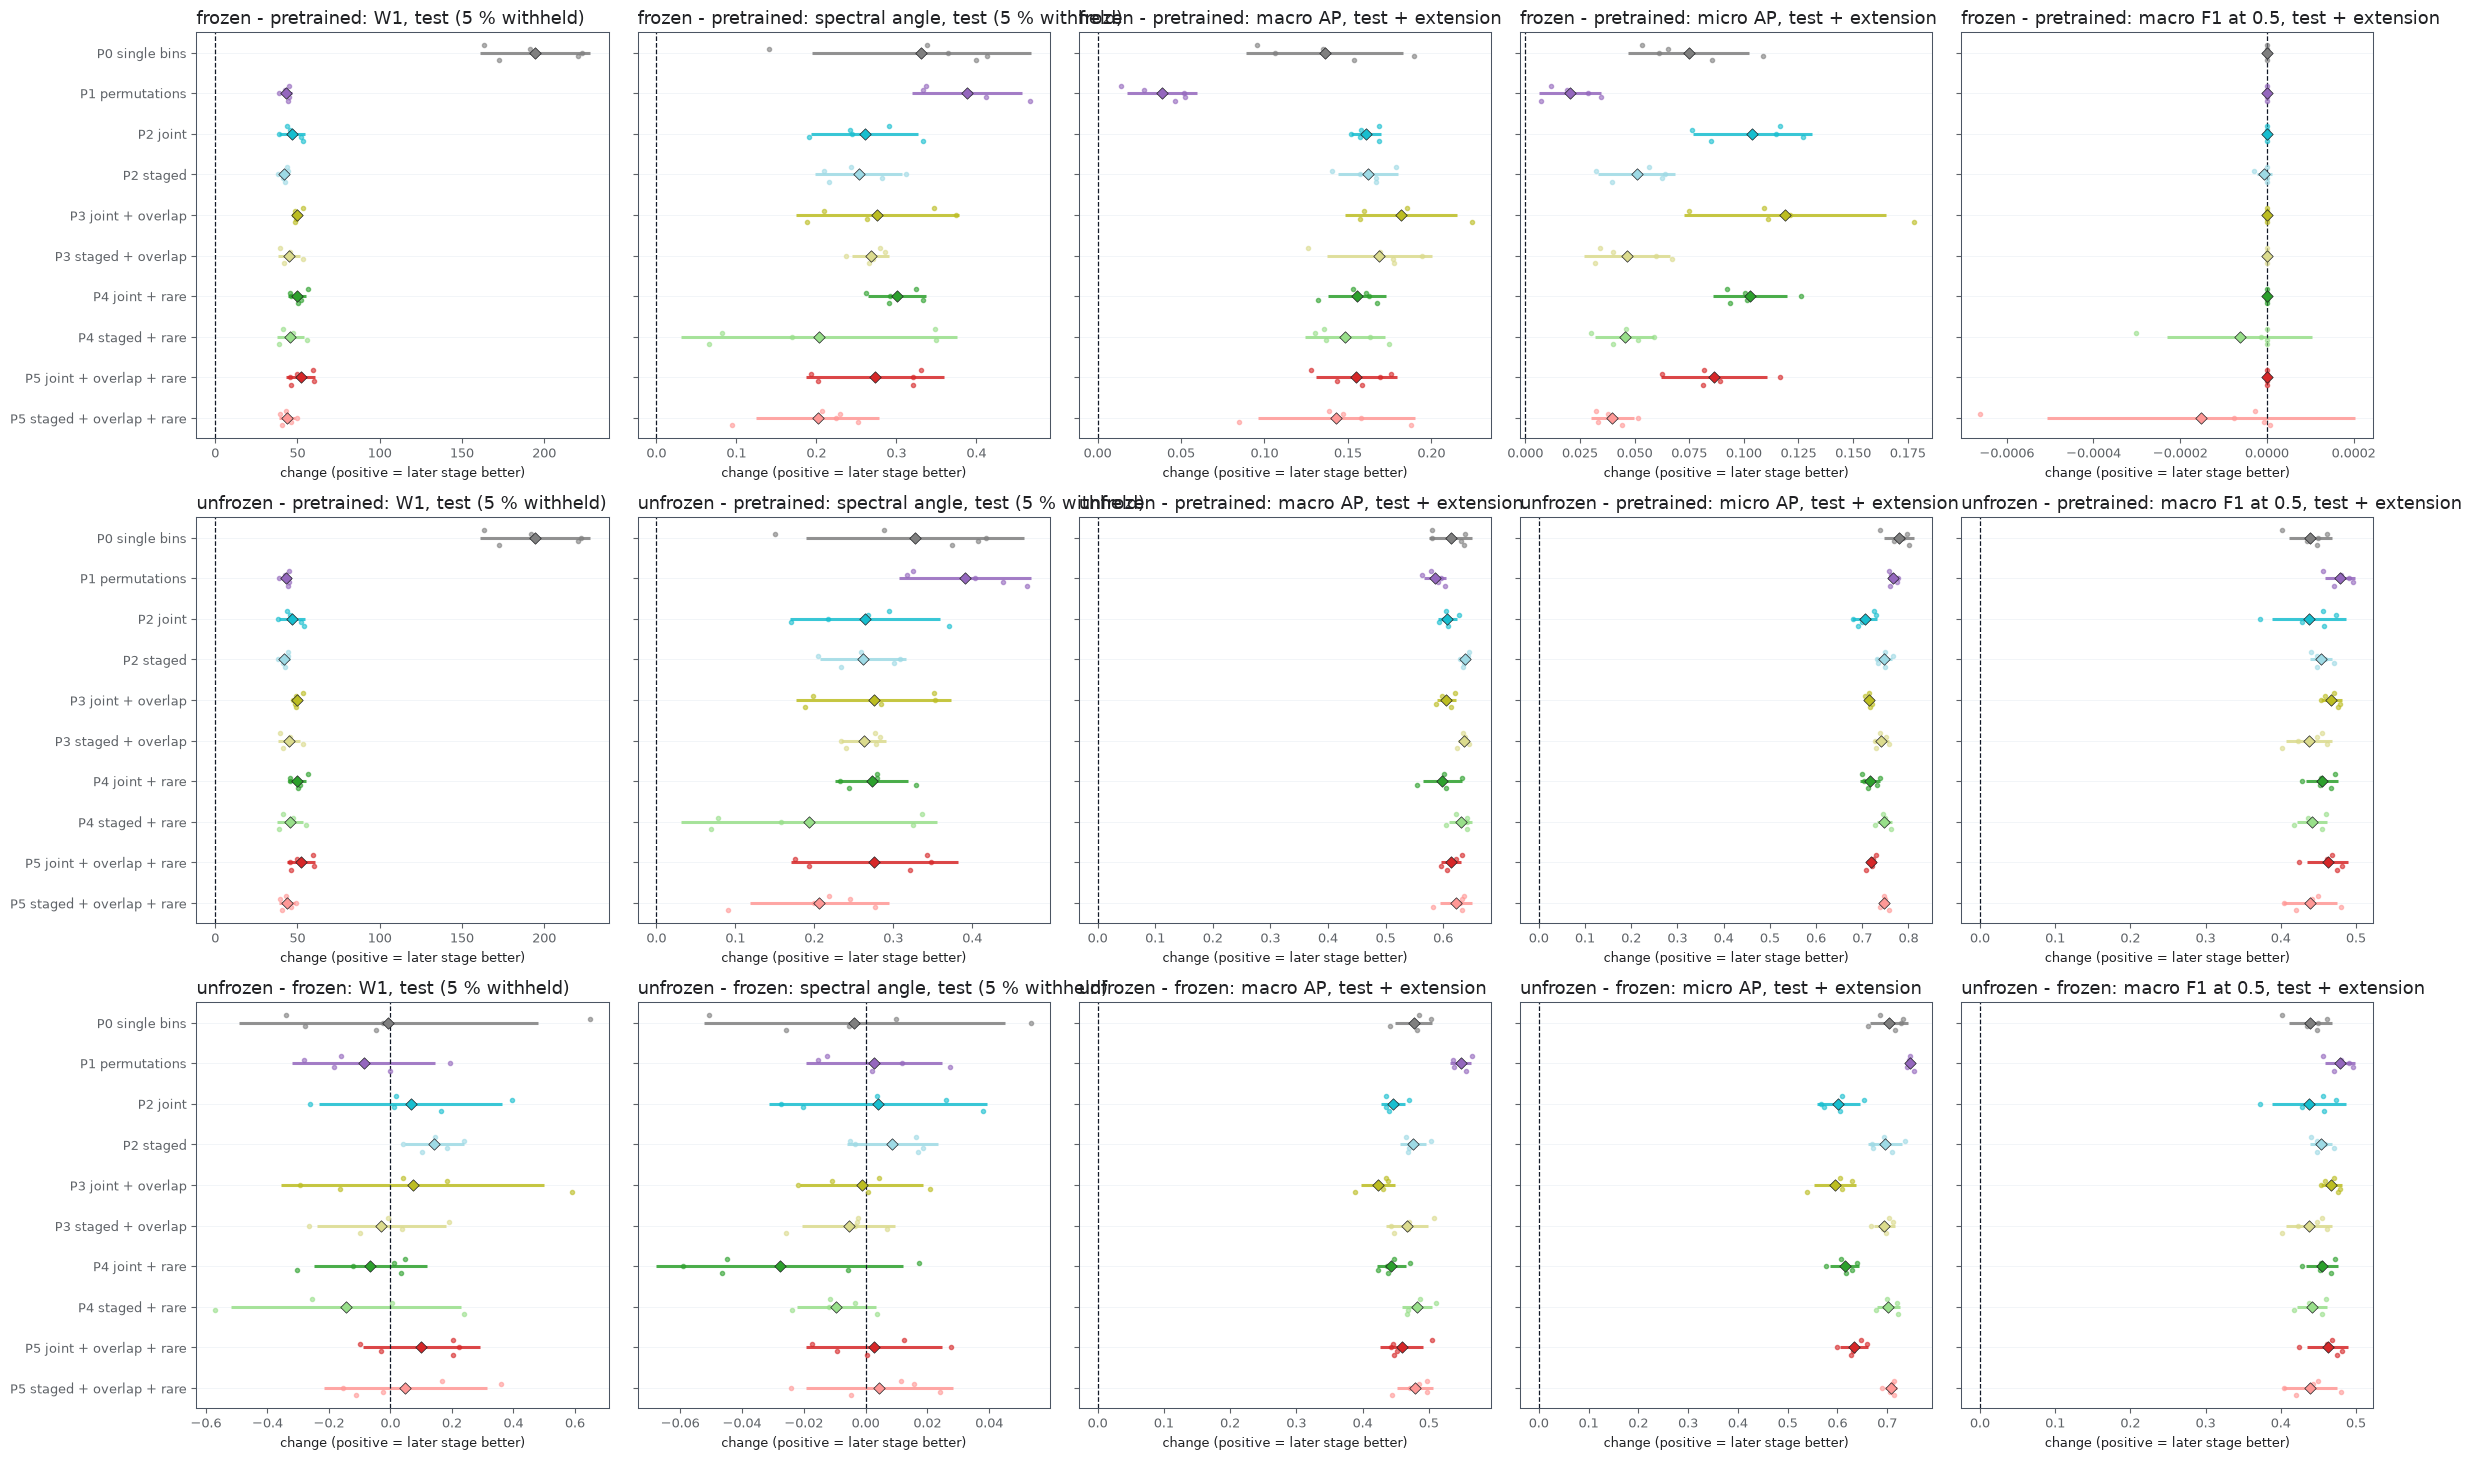

In [7]:
panels = [(f"{name.replace('_minus_', ' - ')}: {title}", {**selector, 'transition': name})
          for name in TRANSITIONS for title, selector in key_panels(reconstruction=('test',), prediction=('test_combined',))]
figures.improvement_forest(transition_summary, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                           paired=transitions, columns=5, xlabel='change (positive = later stage better)', theme=theme);
rows = pd.concat([transition_summary[(transition_summary.family == spec['family']) & (transition_summary.metric == spec['metric'])
                                     & (transition_summary.ranking == spec.get('ranking', 'none'))] for spec in KEY_METRICS])
rows = rows[rows.evaluation.isin(['heldout_image', 'heldout_image_per_image'])]
display(rows.assign(result=interval(rows), column=rows.transition + ' | ' + rows.metric.map(SHORT) + ' | ' + rows.evaluation)
        .pivot_table(index='variant', columns='column', values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- frozen - pretrained: reconstruction cells better/worse 40/0 of 40; head cells better/worse 20/22 of 90.
- unfrozen - pretrained: reconstruction cells better/worse 40/0 of 40; head cells better/worse 90/0 of 90.
- unfrozen - frozen: reconstruction cells better/worse 2/0 of 40; head cells better/worse 90/0 of 90.

### Notes

## Results / Summary

### LLM

- **Observed:** along every lineage the pretrained stage is far below the baseline, the frozen-head stage recovers the reconstruction (40 of 40 reconstruction cells improve over the pretrained stage) but not the head, and the unfrozen stage recovers the head (90 of 90 head cells improve over the frozen stage).
- **Observed:** unfreezing the head barely changes the reconstruction (2 of 40 cells improve over the frozen stage).
- **Interpretation:** real fine-tuning brings the head of every variant back to the baseline's level but not beyond it on this axis; the reconstruction stays worse (43 worsening key-metric cells at the unfrozen stage, 27 of them spectral angle and W1).

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- W1, test (by stage, variants pooled): baseline 3.117; others 3.36-64.55; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.36), worst pretrained (64.55).
- W1, test (unfrozen head, per variant): baseline 3.117; others 3.025-3.49; 1 of 10 better than the baseline; best P1 permutations (3.025), worst P4 joint + rare (3.49).
  best single cell: P1 permutations, fine-tuned, frozen head (2.938 vs baseline 3.117).
- W1, heldout_image (by stage, variants pooled): baseline 3.076; others 3.401-49.63; 0 of 3 better than the baseline; best fine-tuned, frozen head (3.401), worst pretrained (49.63).
- W1, heldout_image (unfrozen head, per variant): baseline 3.076; others 3.123-3.678; 0 of 10 better than the baseline; best P1 permutations (3.123), worst P0 single bins (3.678).
  best single cell: P1 permutations, fine-tuned, frozen head (2.966 vs baseline 3.076).
- spectral angle, test (by stage, variants pooled): baseline 0.9716; others 1.153-1.429; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.153), worst pretrained (1.429).
- spectral angle, test (unfrozen head, per variant): baseline 0.9716; others 0.9711-1.23; 1 of 10 better than the baseline; best P1 permutations (0.9711), worst P4 staged + rare (1.23).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9711 vs baseline 0.9716).
- spectral angle, heldout_image (by stage, variants pooled): baseline 0.8726; others 1.07-1.47; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.07), worst pretrained (1.47).
- spectral angle, heldout_image (unfrozen head, per variant): baseline 0.8726; others 0.8567-1.194; 1 of 10 better than the baseline; best P1 permutations (0.8567), worst P4 staged + rare (1.194).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.8567 vs baseline 0.8726).
- macro AP, test_combined (by stage, variants pooled): baseline 0.7088; others 0.09429-0.7094; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7094), worst pretrained (0.09429).
- macro AP, test_combined (unfrozen head, per variant): baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
  best single cell: P3 staged + overlap, fine-tuned, unfrozen head (0.7124 vs baseline 0.7088).
- macro AP, heldout_image_per_image (by stage, variants pooled): baseline 0.5831; others 0.4448-0.5741; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5741), worst fine-tuned, frozen head (0.4448).
- macro AP, heldout_image_per_image (unfrozen head, per variant): baseline 0.5831; others 0.5684-0.5783; 0 of 10 better than the baseline; best P4 joint + rare (0.5783), worst P2 staged (0.5684).
  best single cell: P4 joint + rare, fine-tuned, unfrozen head (0.5783 vs baseline 0.5831).
- micro AP, test_combined (by stage, variants pooled): baseline 0.8828; others 0.1399-0.8783; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8783), worst pretrained (0.1399).
- micro AP, test_combined (unfrozen head, per variant): baseline 0.8828; others 0.8717-0.886; 1 of 10 better than the baseline; best P0 single bins (0.886), worst P5 joint + overlap + rare (0.8717).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.886 vs baseline 0.8828).
- micro AP, heldout_image_per_image (by stage, variants pooled): baseline 0.8048; others 0.3553-0.8001; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8001), worst fine-tuned, frozen head (0.3553).
- micro AP, heldout_image_per_image (unfrozen head, per variant): baseline 0.8048; others 0.7922-0.8057; 2 of 10 better than the baseline; best P2 joint (0.8057), worst P2 staged (0.7922).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.8057 vs baseline 0.8048).
- macro F1 at 0.5, test_combined (by stage, variants pooled): baseline 0.4908; others 1.535e-07-0.4512; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4512), worst fine-tuned, frozen head (1.535e-07).
- macro F1 at 0.5, test_combined (unfrozen head, per variant): baseline 0.4908; others 0.4376-0.4787; 0 of 10 better than the baseline; best P1 permutations (0.4787), worst P2 joint (0.4376).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.4787 vs baseline 0.4908).
- macro F1 at 0.5, heldout_image_per_image (by stage, variants pooled): baseline 0.1753; others 0-0.1808; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.1808), worst fine-tuned, frozen head (0).
- macro F1 at 0.5, heldout_image_per_image (unfrozen head, per variant): baseline 0.1753; others 0.1666-0.1988; 7 of 10 better than the baseline; best P5 staged + overlap + rare (0.1988), worst P0 single bins (0.1666).
  best single cell: P5 staged + overlap + rare, fine-tuned, unfrozen head (0.1988 vs baseline 0.1753).

### Person